# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Assignment  93: ANN Keras - Rupesh Patil</p>

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 1</p>

## Q1. Install and load the latest versions of TensorFlow and Keras. Print their versions.
---

## Answer

In [1]:
%pip install tensorflow keras

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow
tensorflow.__version__

'2.13.0'

In [3]:
import keras
keras.__version__

'2.13.1'

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 2</p>

## Q2: Load the Wine Quality dataset and explore its dimensions
##### Dataset Link : [https://www.kaggle.com/datasets/nareshbhat/wine-quality-binary-classification](https://www.kaggle.com/datasets/nareshbhat/wine-quality-binary-classification)
---

## Answer :

In [4]:
# Read the dataset
import pandas as pd
df = pd.read_csv('wine.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,bad
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,bad
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,good
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad


In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   object 
dtypes: float64(11), object(1)
memory usage: 150.0+ KB


In [6]:
# Descriptive Statistics Numeric variables
df.describe(exclude='object').T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [7]:
df.describe(include='object').T

,count,unique,top,freq
quality,1599,2,good,855


<Axes: title={'center': 'Wine Quality CountPlot'}>

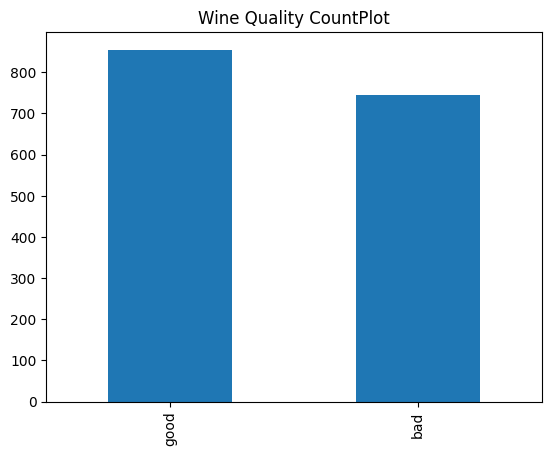

In [8]:
# Univariate analysis categorical feature
df['quality'].value_counts().plot(kind='bar',title='Wine Quality CountPlot')

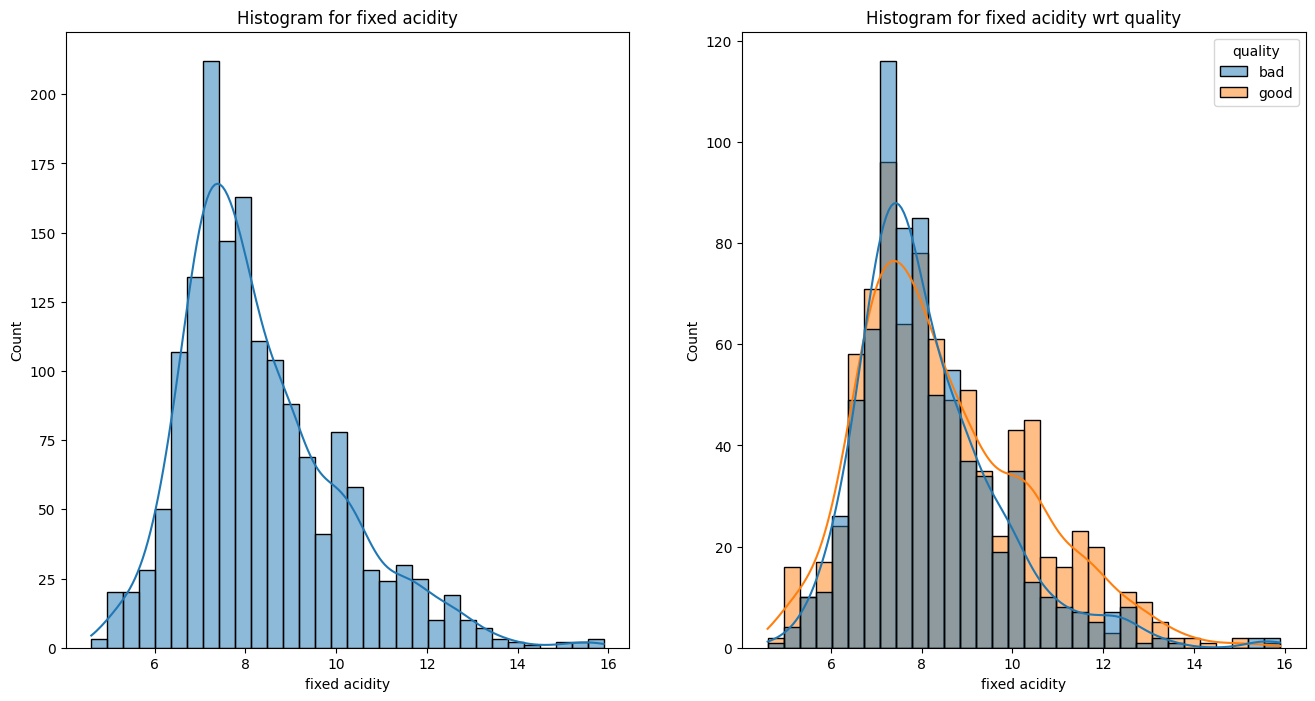

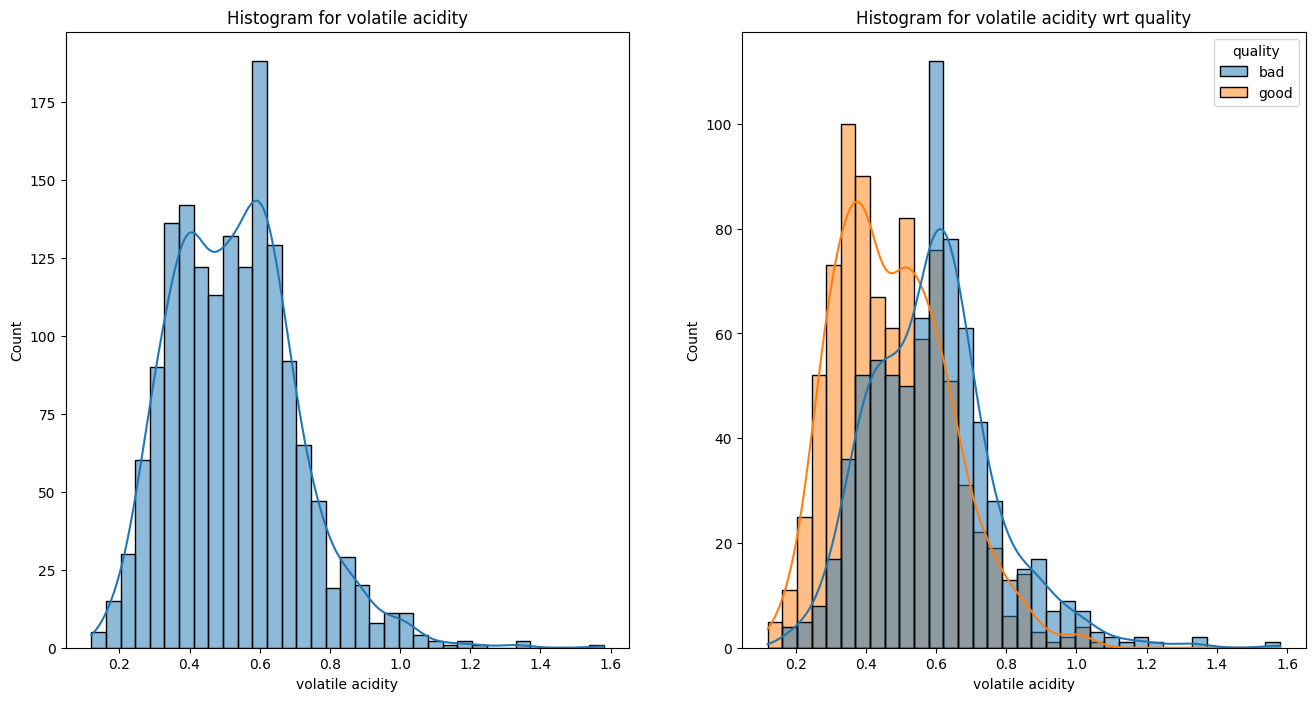

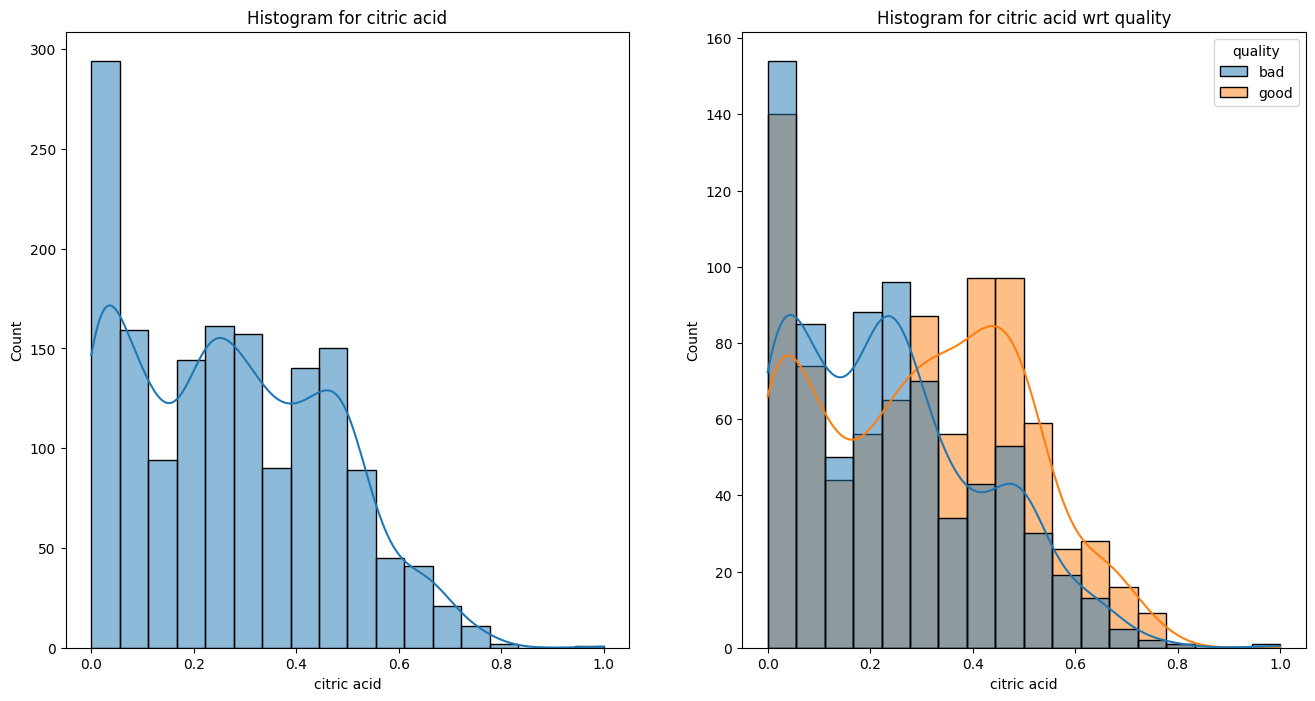

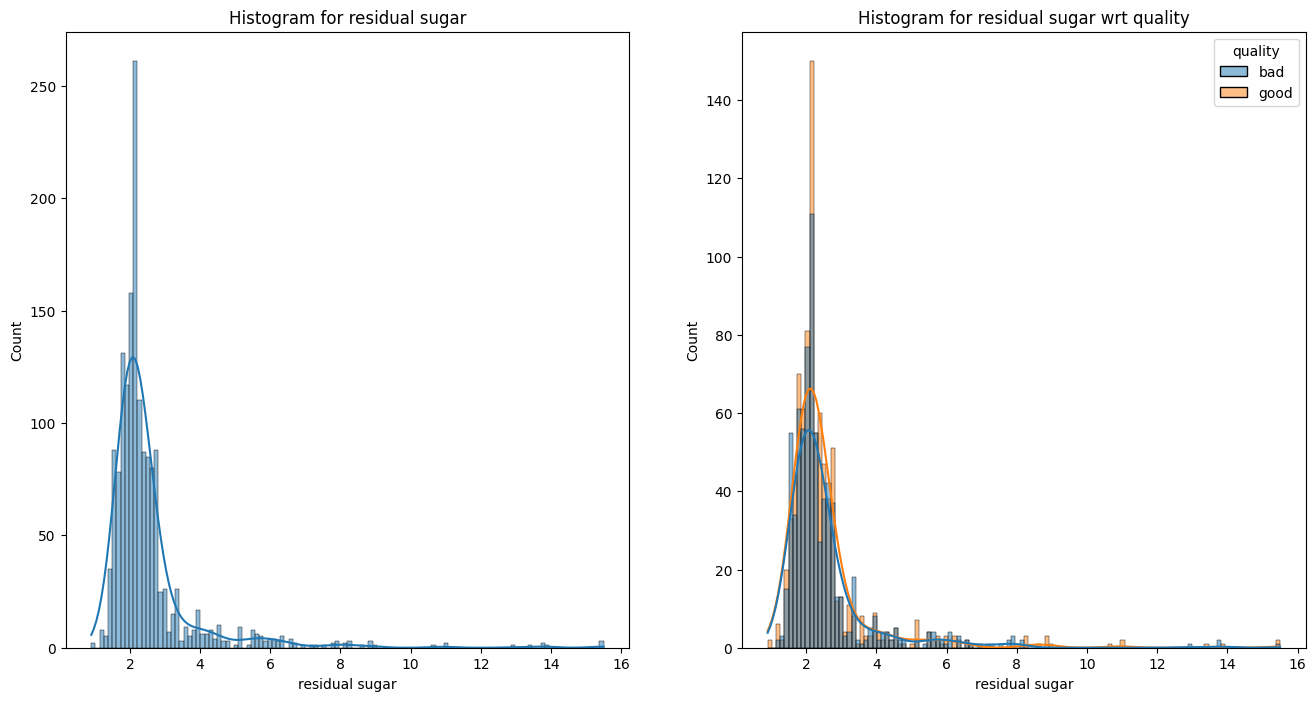

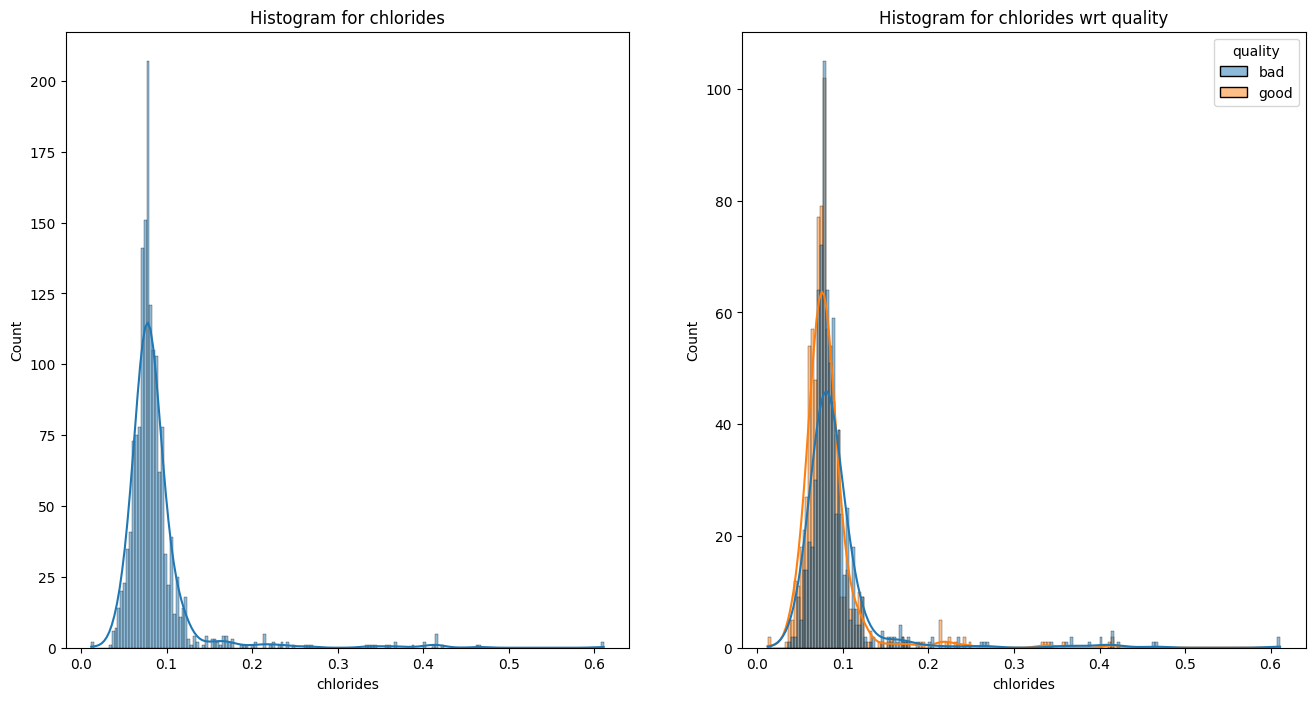

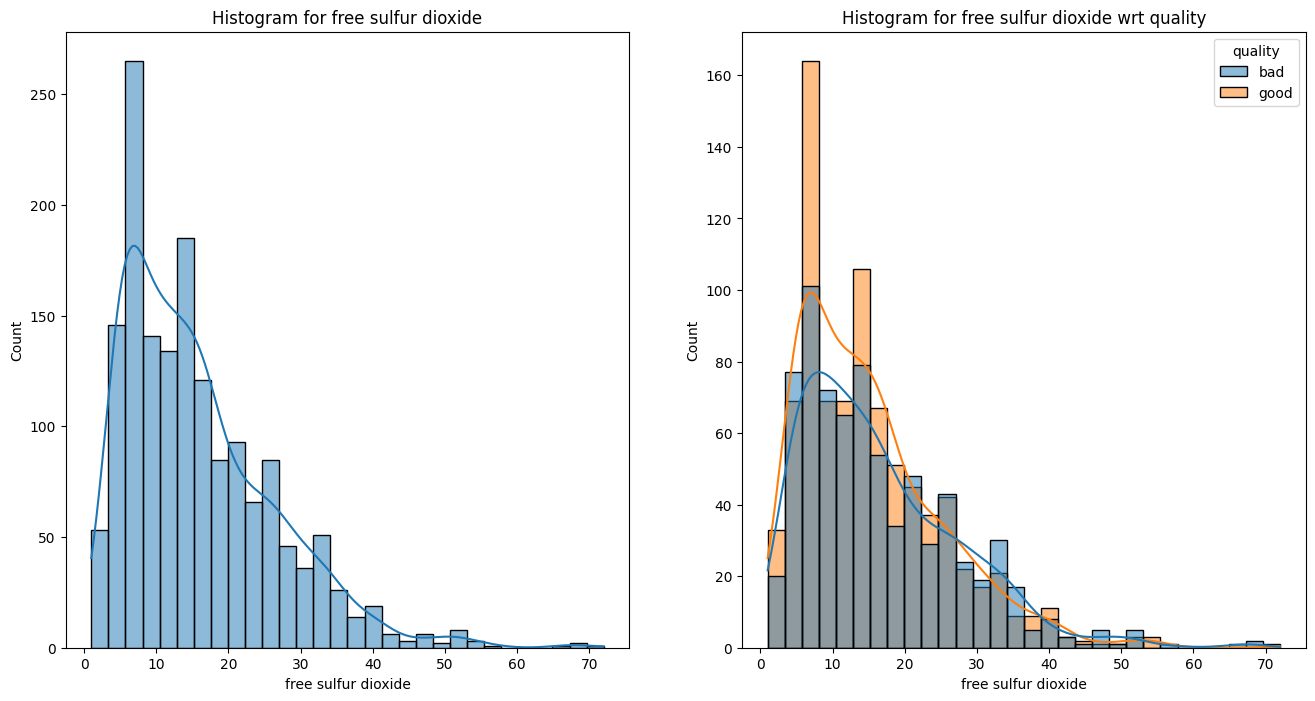

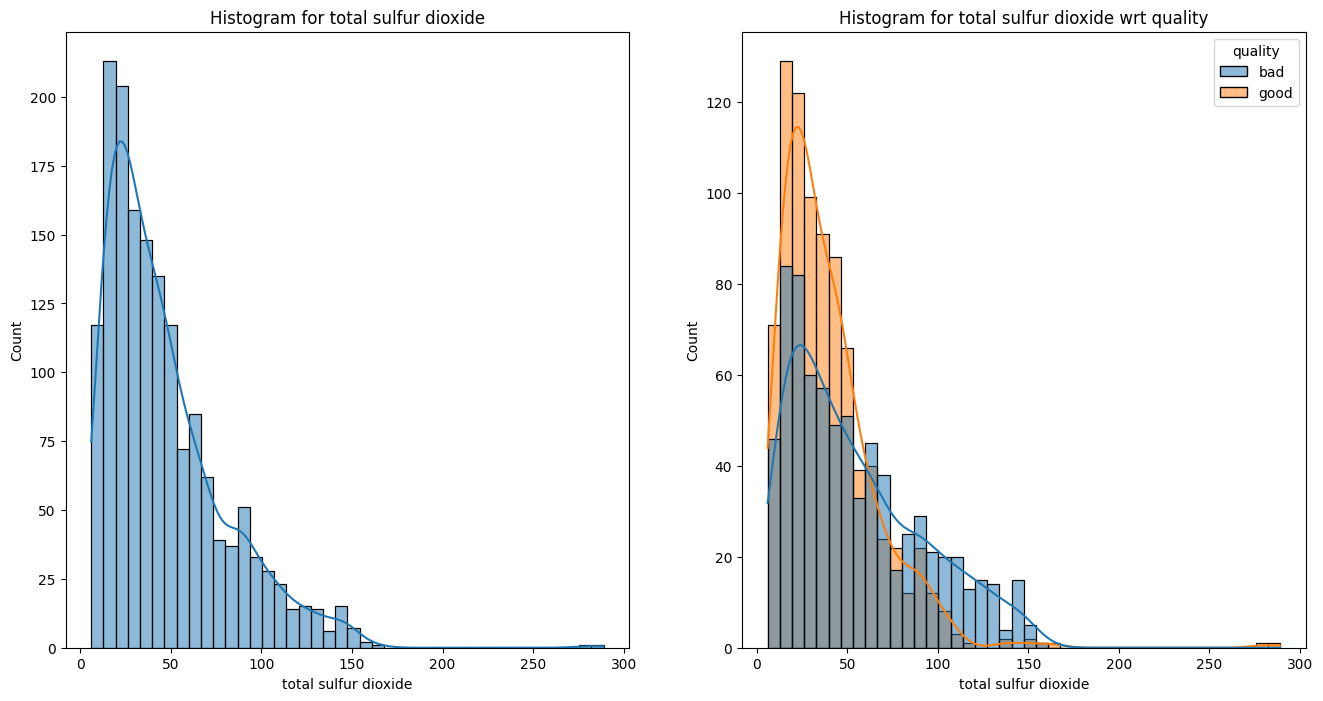

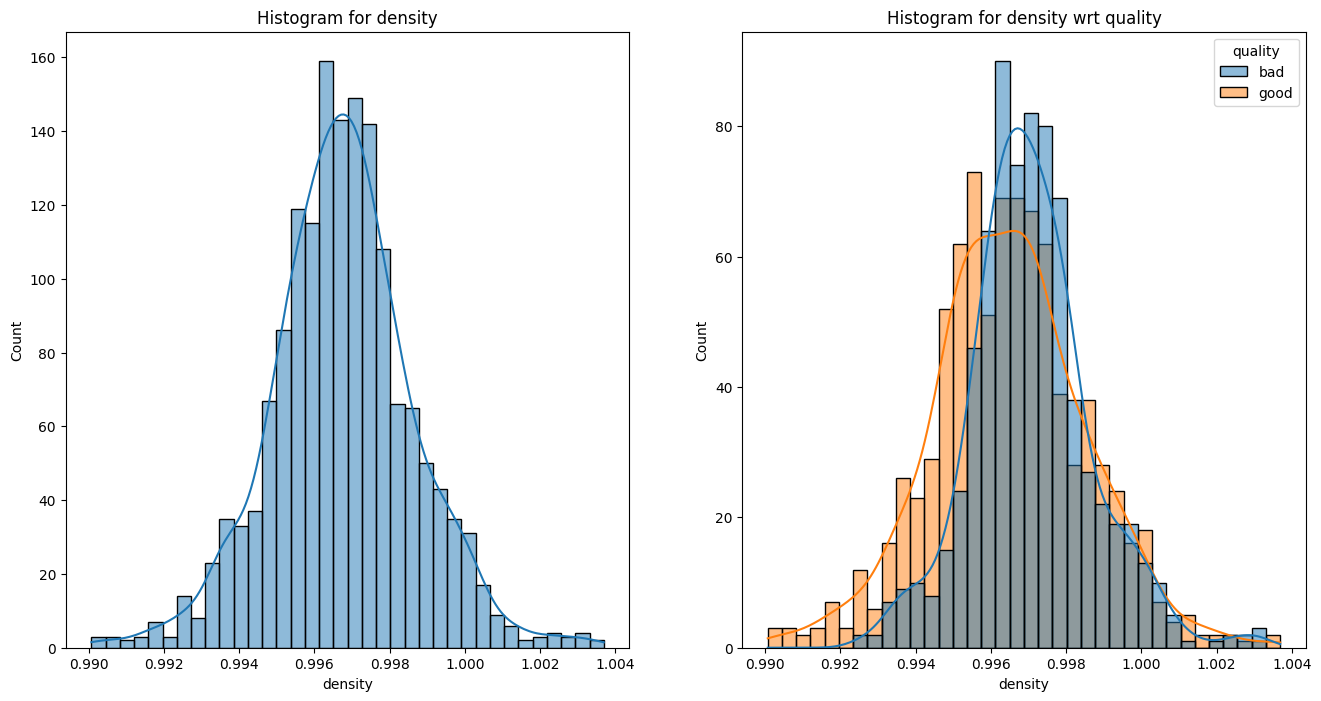

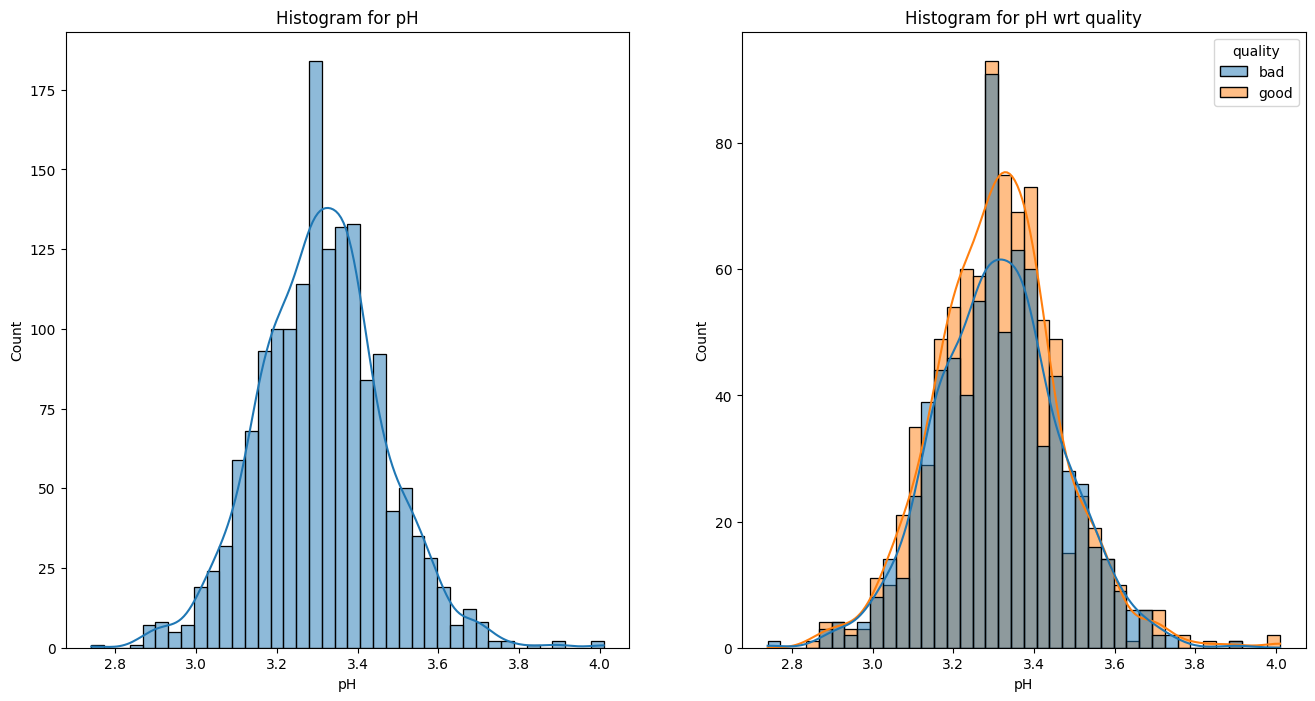

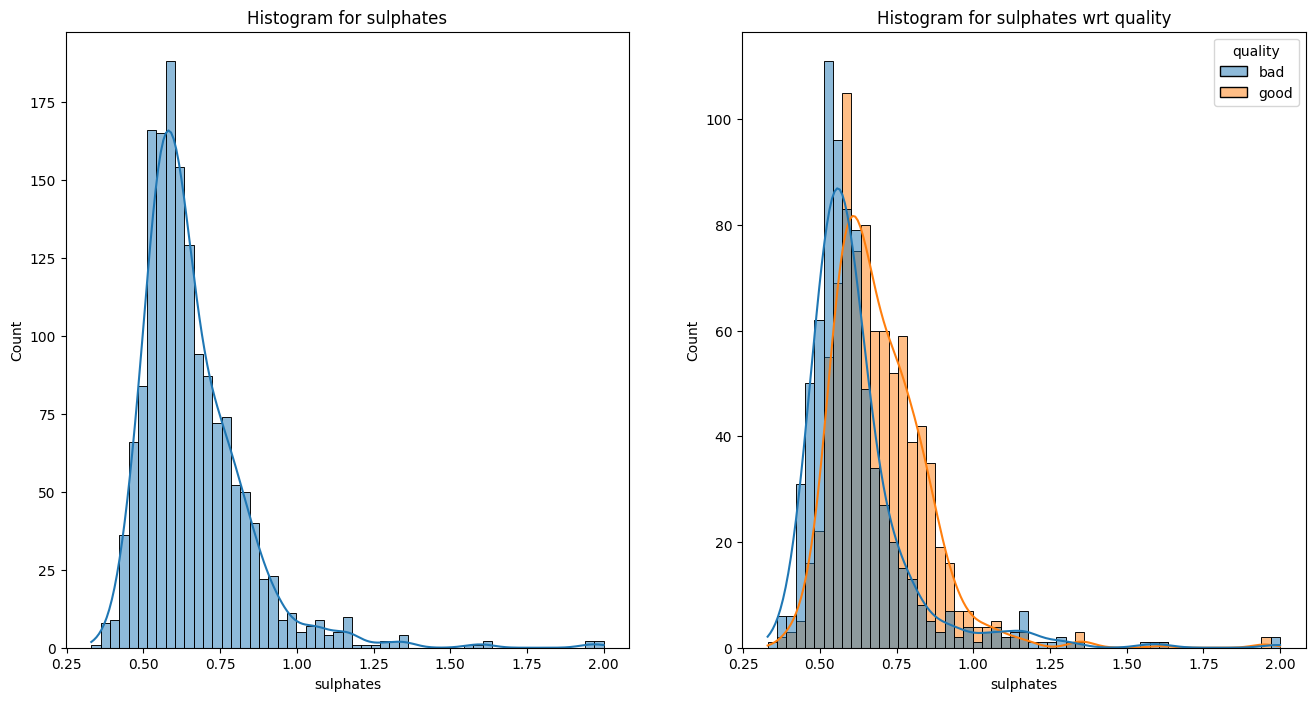

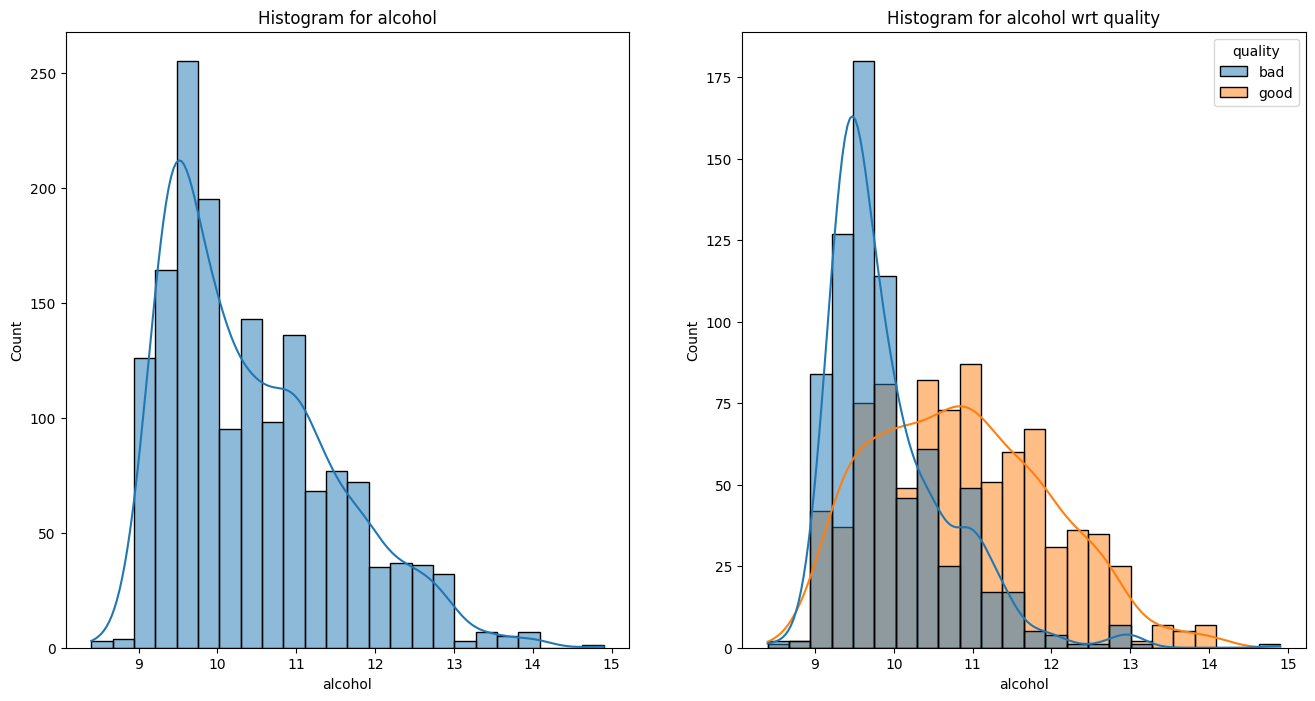

In [9]:
# Histogram for continous features
import seaborn as sns
import matplotlib.pyplot as plt
for i in df.columns:
    if df[i].dtype!='object':
        plt.figure(figsize=(16,8))
        plt.subplot(1,2,1)
        sns.histplot(data=df,x=i,kde=True)
        plt.title(f'Histogram for {i}')
        
        plt.subplot(1,2,2)
        sns.histplot(data=df,x=i,hue='quality',kde=True)
        plt.title(f'Histogram for {i} wrt quality')

        plt.show()   

In [10]:
# Correlation heatmap
df.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595


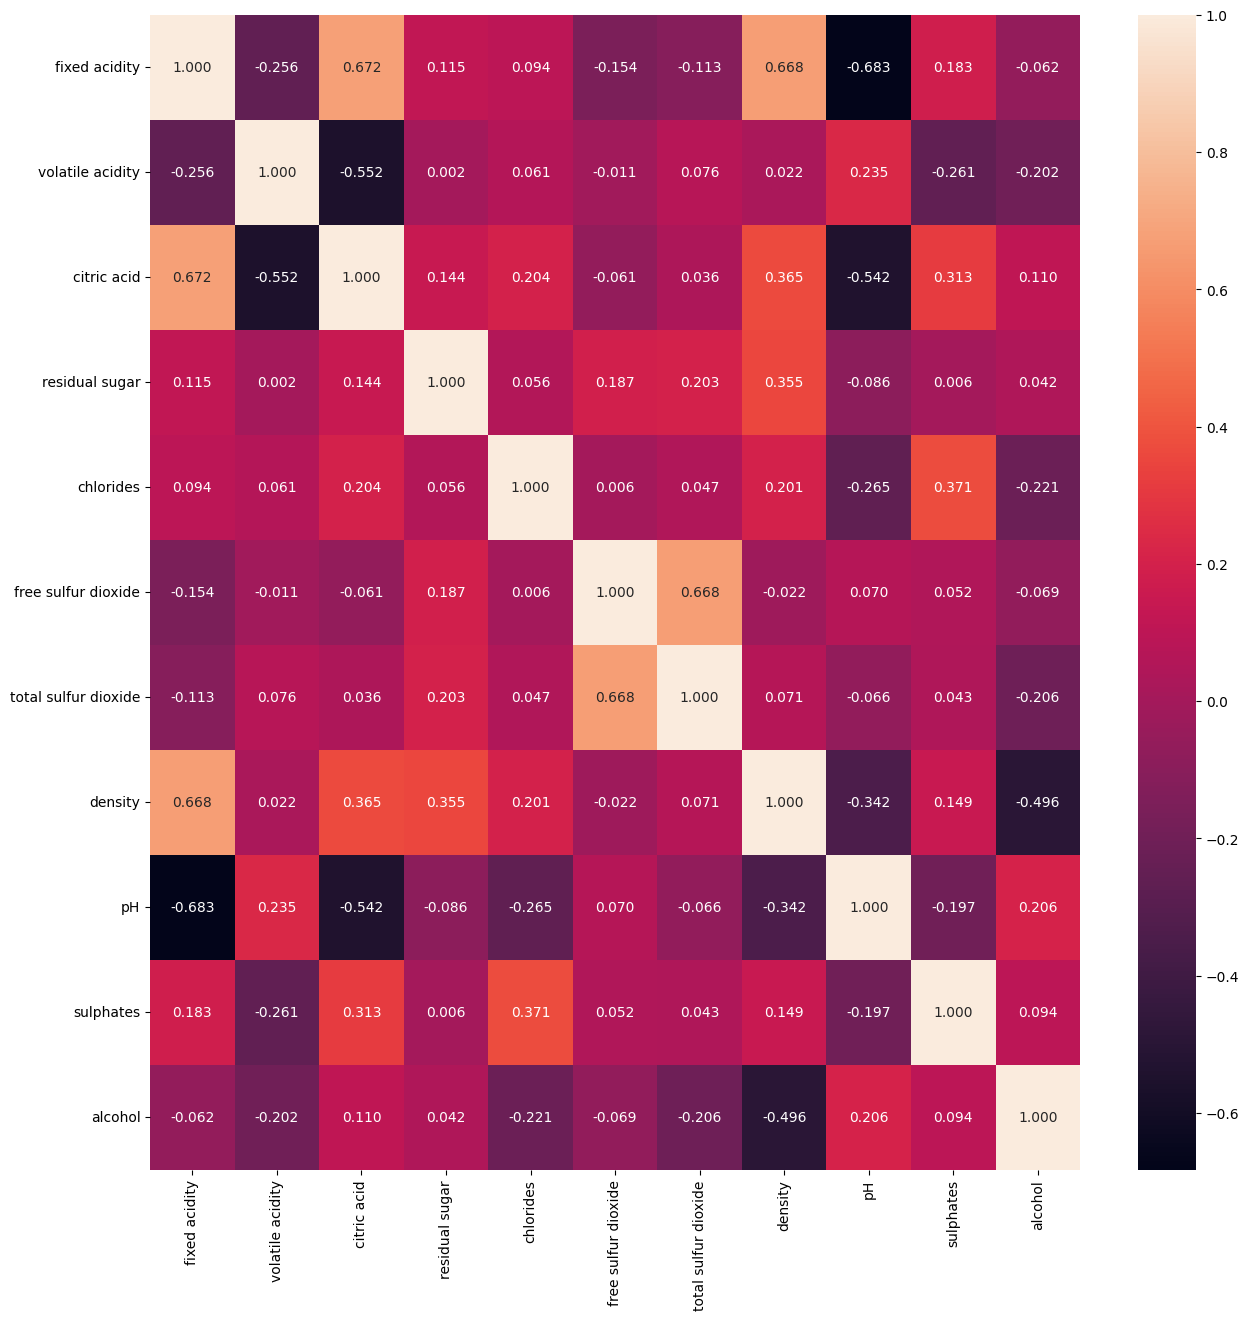

In [11]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.3f')
plt.show()

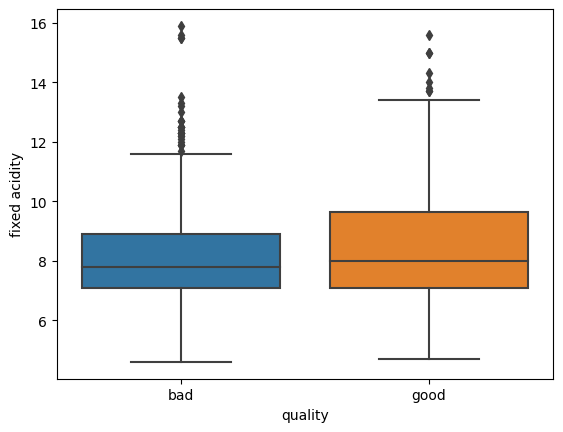

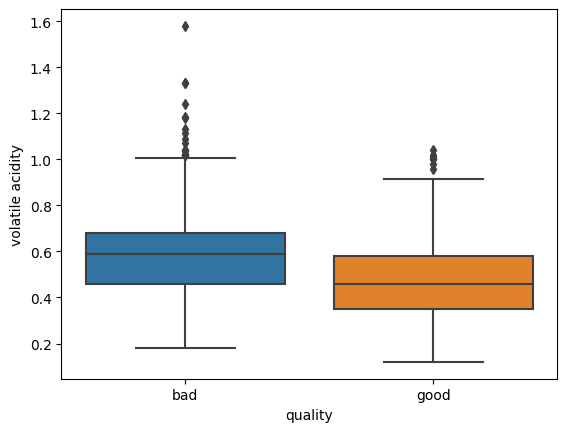

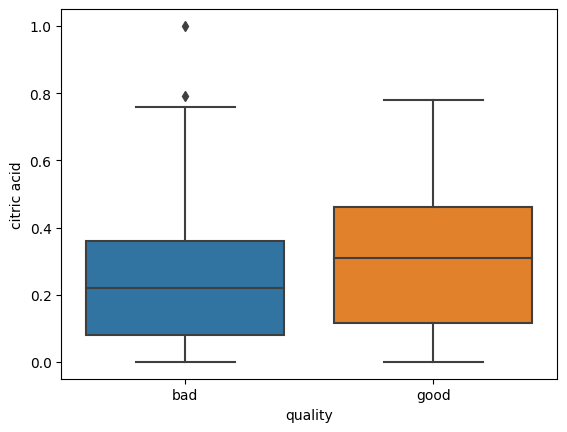

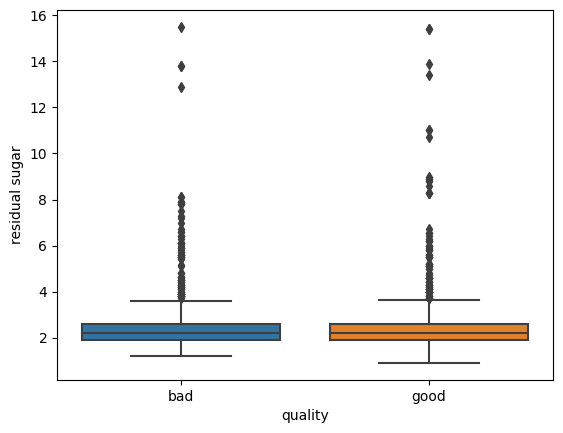

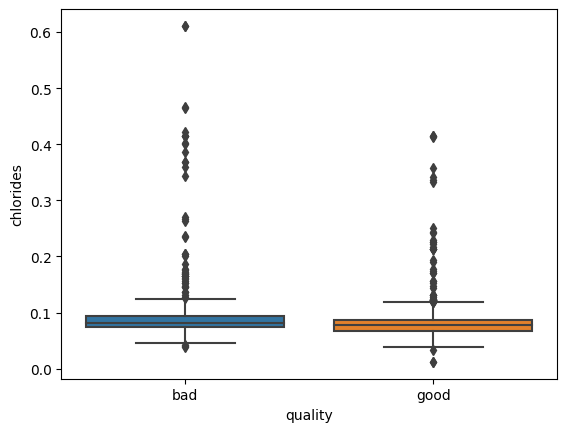

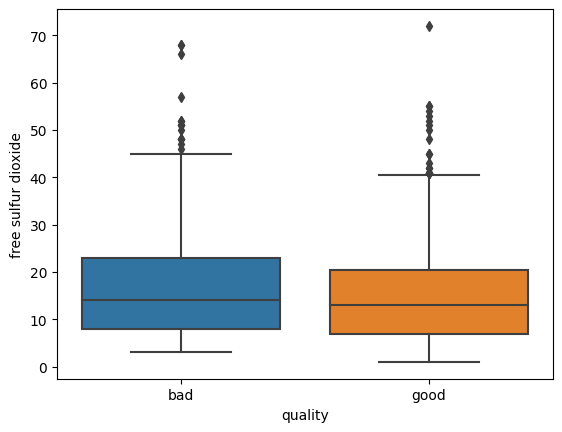

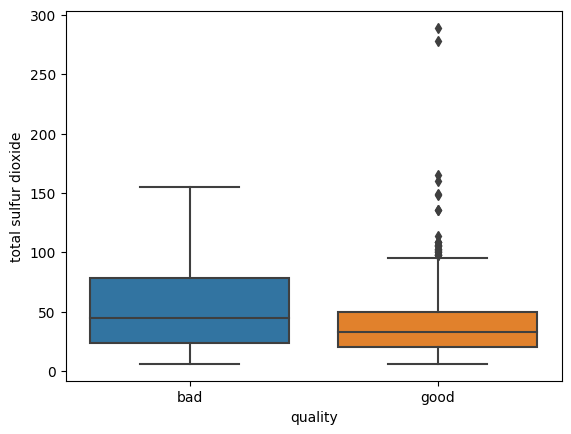

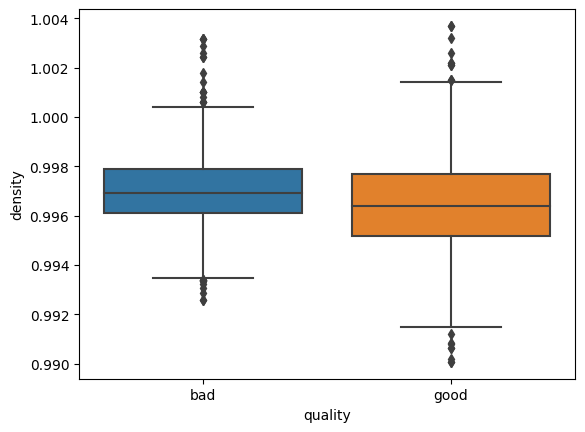

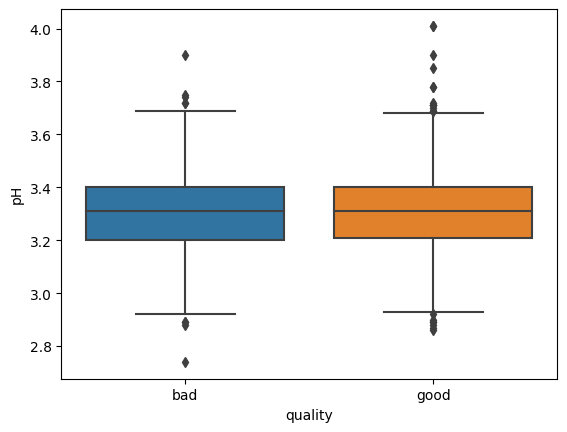

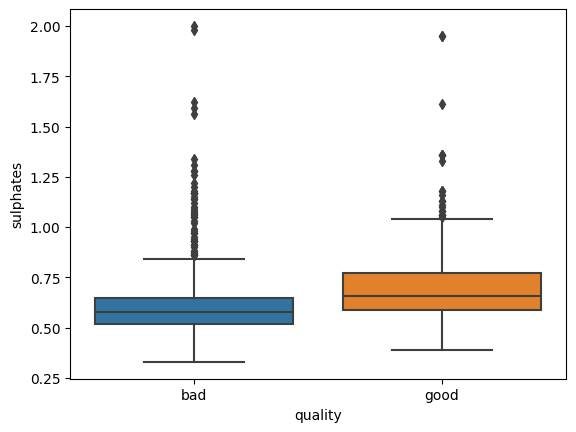

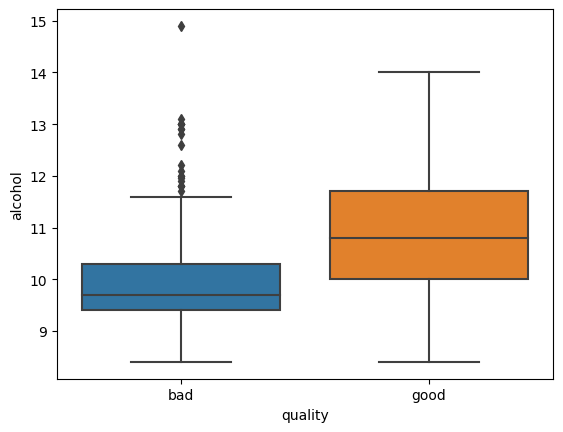

In [12]:
# Box Plot wrt Wine Quality
for i in df.columns:
    if df[i].dtype!='object':
        sns.boxplot(data=df,x='quality',y=i)
        plt.show()

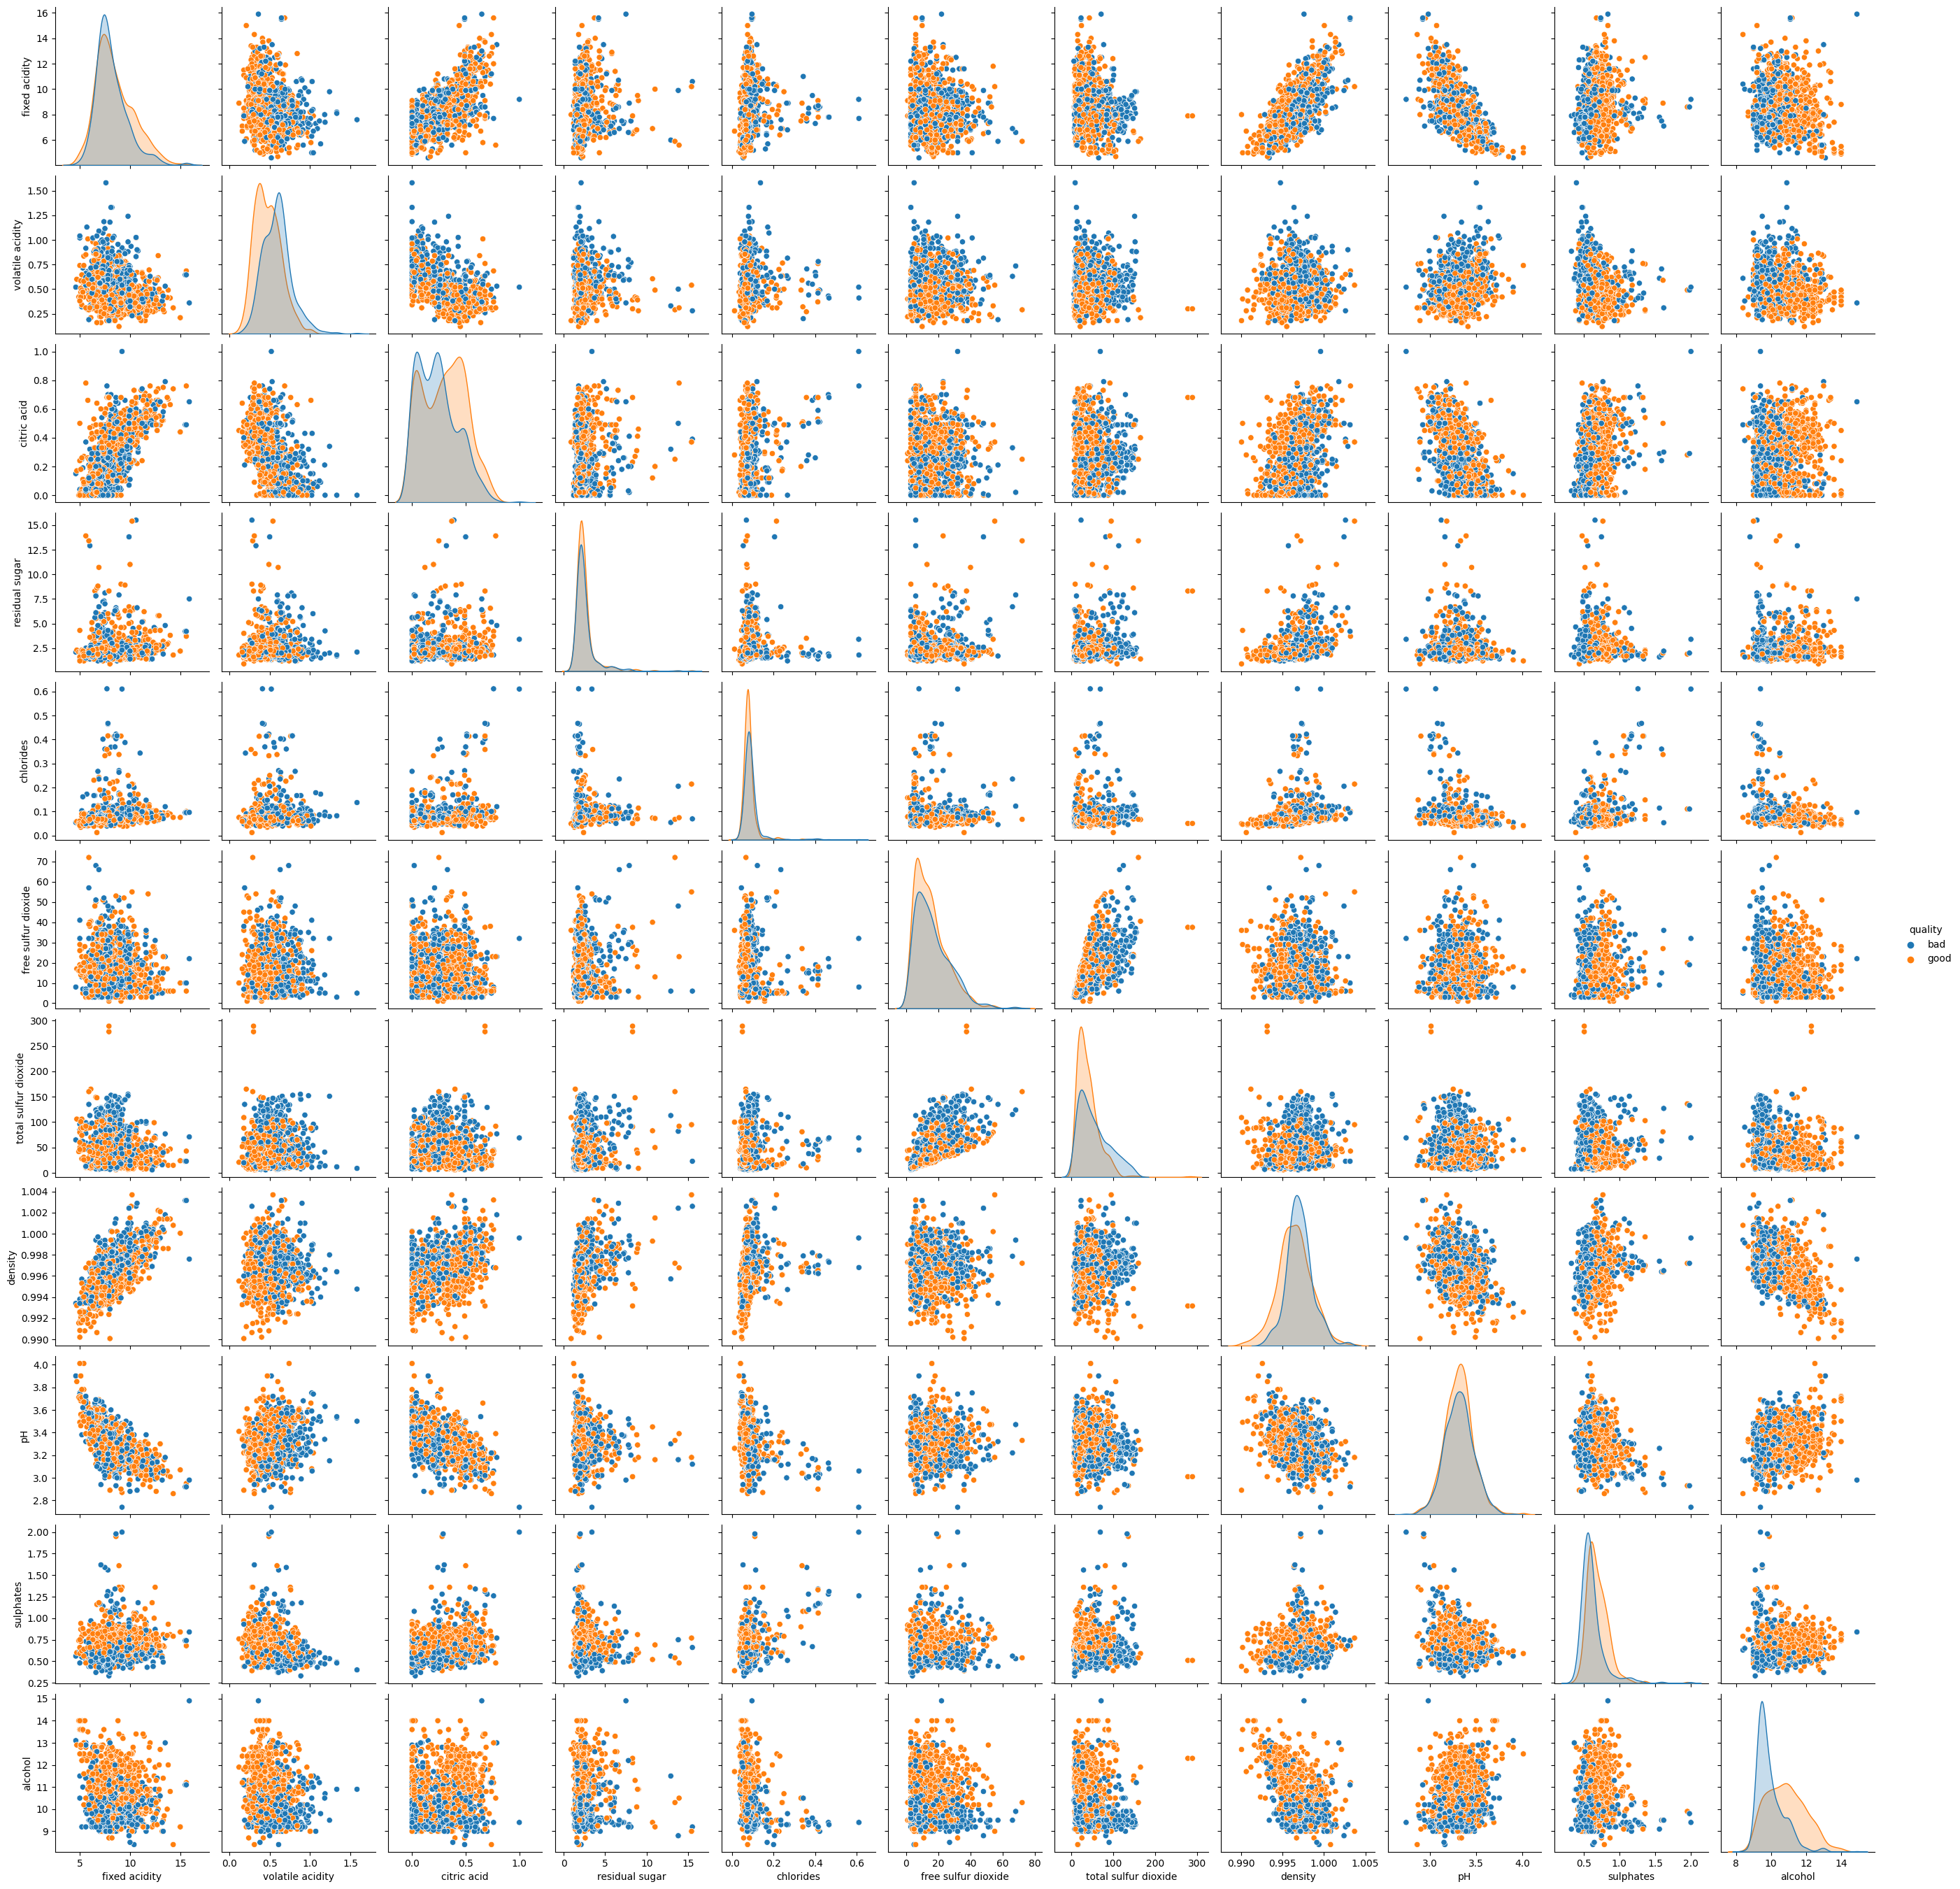

In [13]:
# Multivariate Analysis
sns.pairplot(data=df,hue='quality')

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 3</p>

## Q3: Check for null values, identify categorical variables, and encode them.
---

## Answer: 

In [14]:
# Checking missing values
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [15]:
# Categorical Features
df.columns[df.dtypes=='object']

Index(['quality'], dtype='object')

In [16]:
# Label Encoding the quality column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['quality'] = le.fit_transform(df['quality'])

In [17]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [18]:
# Checking duplicated values
df.duplicated().sum()

240

In [19]:
df = df.drop_duplicates(keep='first')

In [20]:
df.shape

(1359, 12)

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 4</p>

## Q4: Separate the features and target variables from the dataframe.
---

## Answer :

In [21]:
X = df.drop(labels=['quality'],axis=1)
Y = df[['quality']]

In [22]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 5</p>

## Q5 :  Perform a train-test split and divide the data into training, validation, and test datasets.
---

## Answer :

In [23]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X,Y,test_size=0.2,random_state=42)

In [24]:
xtrain.shape

(1087, 11)

In [25]:
xtest.shape

(272, 11)

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 6</p>

## Q6. Scale the dataset using an appropriate scaling technique.
---

## Answer :

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain_scl = pd.DataFrame(scaler.fit_transform(xtrain),columns=xtrain.columns)
xtest_scl = pd.DataFrame(scaler.transform(xtest),columns=xtest.columns)

In [27]:
xtest_scl.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.343944,0.517338,-1.194658,0.933678,-0.106593,0.896271,-0.055555,0.591961,0.200156,-0.746237,-0.857565
1,-0.054125,0.601441,-0.887420,-0.311698,-0.316290,0.896271,0.395101,-0.170479,-0.128400,0.519851,0.425831
2,0.061803,-0.884392,0.802390,-0.165183,-0.506923,-0.362070,-0.836691,-0.642977,-0.916933,0.865147,0.700844
3,0.931263,-0.211562,1.570486,0.713906,0.084040,-0.652457,-0.115642,1.987978,-0.128400,-0.458489,-1.315921
4,-1.155440,2.760106,-1.399484,-0.384955,-0.125657,0.121907,-0.686473,-1.249707,1.842934,-0.631138,0.700844


In [28]:
xtest_scl.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.343944,0.517338,-1.194658,0.933678,-0.106593,0.896271,-0.055555,0.591961,0.200156,-0.746237,-0.857565
1,-0.054125,0.601441,-0.887420,-0.311698,-0.316290,0.896271,0.395101,-0.170479,-0.128400,0.519851,0.425831
2,0.061803,-0.884392,0.802390,-0.165183,-0.506923,-0.362070,-0.836691,-0.642977,-0.916933,0.865147,0.700844
3,0.931263,-0.211562,1.570486,0.713906,0.084040,-0.652457,-0.115642,1.987978,-0.128400,-0.458489,-1.315921
4,-1.155440,2.760106,-1.399484,-0.384955,-0.125657,0.121907,-0.686473,-1.249707,1.842934,-0.631138,0.700844


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 7</p>

## Q7: Create at least 2 hidden layers and an output layer for the binary categorical variables.
---

## Answer :

In [29]:
from keras.layers import Dense, Dropout, BatchNormalization

In [30]:
layer1 = Dense(128,input_dim=xtrain.shape[1],activation='relu')
layer2 = BatchNormalization()
layer3 = Dropout(0.2)

layer4 = Dense(64,activation='relu')
layer5 = BatchNormalization()
layer6 = Dropout(0.2)

output = Dense(1,activation='sigmoid')

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 8</p>

## Q8: Create a Sequential model and add all the layers to it.
---

## Answer :

In [31]:
from keras.models import Sequential

In [32]:
model = Sequential()
model.add(layer1)
model.add(layer2)
model.add(layer3)
model.add(layer4)
model.add(layer5)
model.add(layer6)
model.add(output)

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 9</p>

## Q9: Print the summary of the model architecture.
---

## Answer :

In [33]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               1536      
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 64)                0

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 10</p>

## Q10: Set the loss function(‘binary_crossentropy’), optimizer, and include the accuracy metric in the model.
---

## Answer :

In [34]:
from keras.optimizers import Adam
loss = 'binary_crossentropy'
optimizer = Adam(learning_rate=0.0001)
metrics = ['accuracy']

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 11</p>

## Q11: Compile the model with the specified loss function, optimizer, and metrics.
---

## Answer :

In [35]:
model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 12</p>

## Q12: Fit the model to the training data using appropriate batch size and number of epochs.
---

## Answer :

In [36]:
hist = model.fit(xtrain_scl, ytrain, epochs=100, validation_split=0.2, batch_size=64)

Epoch 1/100
14/14 [==============================] - 2s 24ms/step - loss: 0.8740 - accuracy: 0.5075 - val_loss: 0.6640 - val_accuracy: 0.6193
Epoch 2/100
14/14 [==============================] - 0s 6ms/step - loss: 0.7808 - accuracy: 0.5512 - val_loss: 0.6563 - val_accuracy: 0.6468
Epoch 3/100
14/14 [==============================] - 0s 6ms/step - loss: 0.7674 - accuracy: 0.5800 - val_loss: 0.6519 - val_accuracy: 0.6284
Epoch 4/100
14/14 [==============================] - 0s 5ms/step - loss: 0.7302 - accuracy: 0.6018 - val_loss: 0.6504 - val_accuracy: 0.6651
Epoch 5/100
14/14 [==============================] - 0s 7ms/step - loss: 0.6738 - accuracy: 0.6341 - val_loss: 0.6506 - val_accuracy: 0.6560
Epoch 6/100
14/14 [==============================] - 0s 6ms/step - loss: 0.6684 - accuracy: 0.6467 - val_loss: 0.6514 - val_accuracy: 0.6284
Epoch 7/100
14/14 [==============================] - 0s 6ms/step - loss: 0.6560 - accuracy: 0.6559 - val_loss: 0.6526 - val_accuracy: 0.6284
Epoch 8/100


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 13</p>

## Q13: Obtain the model's parameters (weights and biases).
---

## Answer :

In [37]:
model.get_weights()

[array([[-0.01144495,  0.10088858,  0.18050025, ...,  0.20336087,
         -0.20648779, -0.09298193],
        [ 0.1162775 ,  0.01634887, -0.10106491, ..., -0.08744541,
         -0.07184205, -0.09131568],
        [-0.0742211 ,  0.12485402, -0.2100583 , ...,  0.16471635,
         -0.17721784,  0.04361769],
        ...,
        [-0.08659589,  0.12758008,  0.08990222, ..., -0.01862044,
          0.19030695,  0.10491154],
        [-0.15353759, -0.16895324, -0.17666647, ..., -0.05760672,
         -0.17490523, -0.00825015],
        [-0.06639694,  0.10555908,  0.01383781, ..., -0.12567537,
          0.14380395,  0.07230174]], dtype=float32),
 array([ 1.67424965e-03, -3.57182813e-03,  1.87279657e-02, -1.75796952e-02,
        -5.35161654e-03, -8.90088268e-03, -2.46375450e-03, -4.14870447e-03,
         4.12801141e-03, -1.90145653e-02, -1.88385081e-02,  3.86913074e-03,
        -1.61178573e-03, -2.43311767e-02, -3.18514113e-03,  1.56429075e-02,
         2.26352550e-02, -4.51782020e-03,  8.79344589e

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 14</p>

## Q14: Store the model's training history as a Pandas DataFrame.
---

## Answer :

In [41]:
df_history = pd.DataFrame(hist.history)
df_history

,loss,accuracy,val_loss,val_accuracy
0,0.874042,0.507480,0.664045,0.619266
1,0.780779,0.551208,0.656250,0.646789
2,0.767400,0.579977,0.651901,0.628440
3,0.730222,0.601841,0.650364,0.665138
4,0.673813,0.634062,0.650600,0.655963
...,...,...,...,...
95,0.492011,0.761795,0.575984,0.761468
96,0.481160,0.774453,0.575417,0.761468
97,0.482485,0.769850,0.576414,0.761468
98,0.476412,0.754891,0.575713,0.761468


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 15</p>

## Q15 : Plot the training history (e.g., accuracy and loss) using suitable visualization techniques.
---

## Answer :

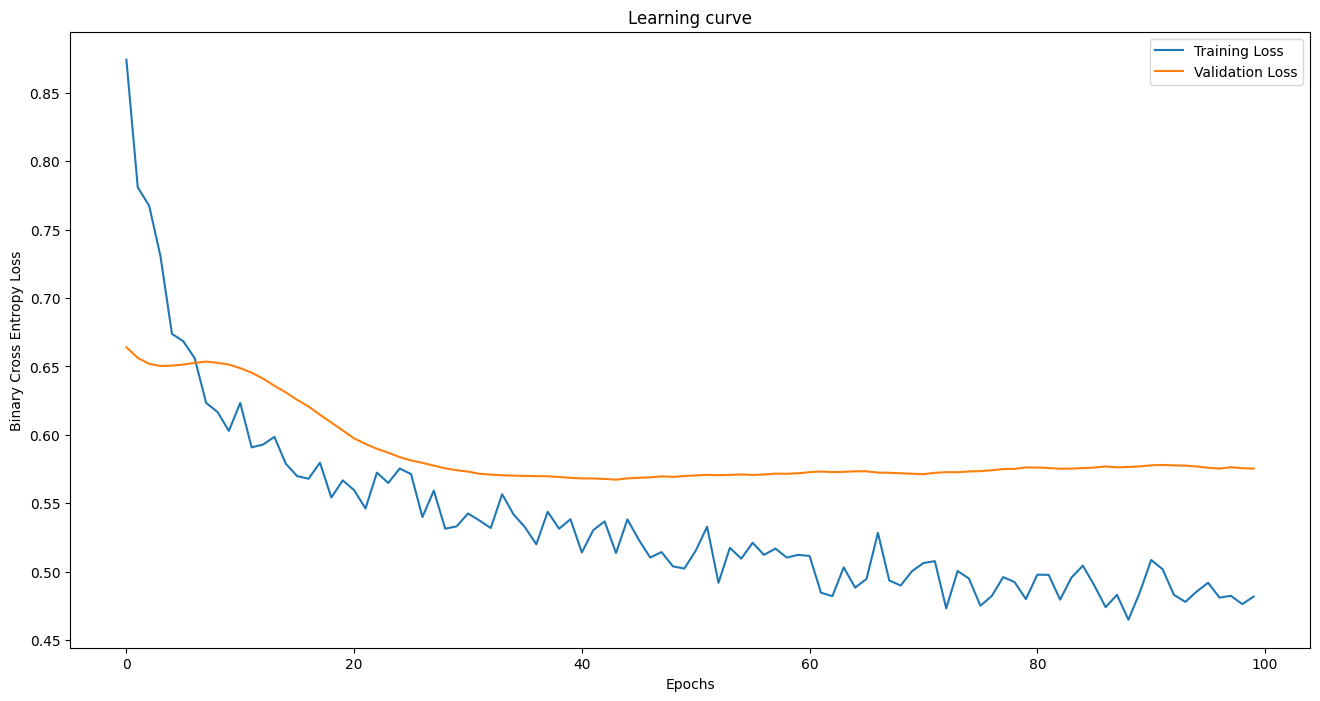

In [42]:
# Learning curve plot
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
plt.plot(hist.history['loss'],label='Training Loss')
plt.plot(hist.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy Loss')
plt.title('Learning curve')
plt.legend()
plt.show()

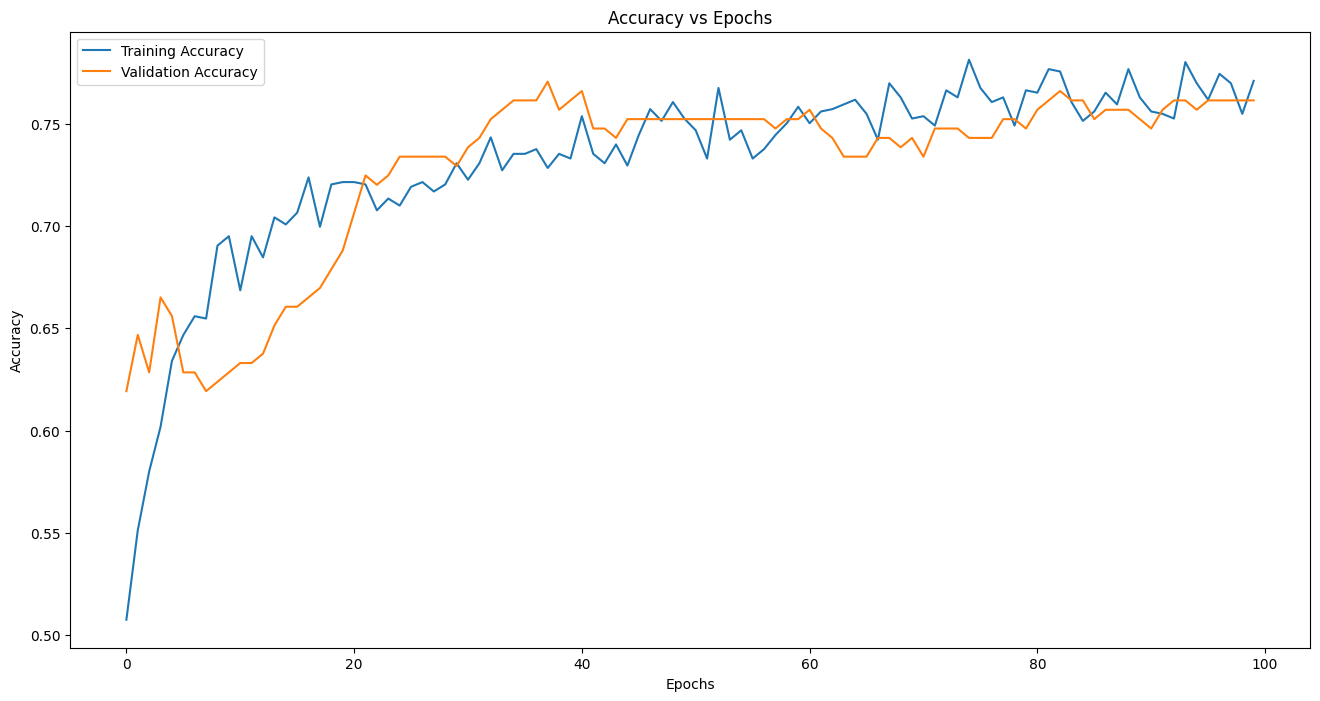

In [51]:
# accuracy plot
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
plt.plot(hist.history['accuracy'],label='Training Accuracy')
plt.plot(hist.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.show()

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Question 16</p>

## Q16: Evaluate the model's performance using the test dataset and report relevant metrics.
---

## Answer:

In [43]:
# Evaluation in testing
model.evaluate(xtest_scl,ytest)

9/9 [==============================] - 0s 2ms/step - loss: 0.4835 - accuracy: 0.7794


[0.4834817945957184, 0.779411792755127]

In [45]:
# Predicting the data
yprob_tr = model.predict(xtrain_scl)
yprob_ts = model.predict(xtest_scl)


9/9 [==============================] - 0s 2ms/step


In [46]:
# Predictions for testing
ypred_ts = []
for i in yprob_ts:
    if i>=0.5:
        ypred_ts.append(1)
    else:
        ypred_ts.append(0)

In [47]:
ypred_ts[0:5]

[0, 1, 1, 0, 0]

In [48]:
ytest.head()

,quality
55,0
1291,1
1544,1
593,0
1261,0


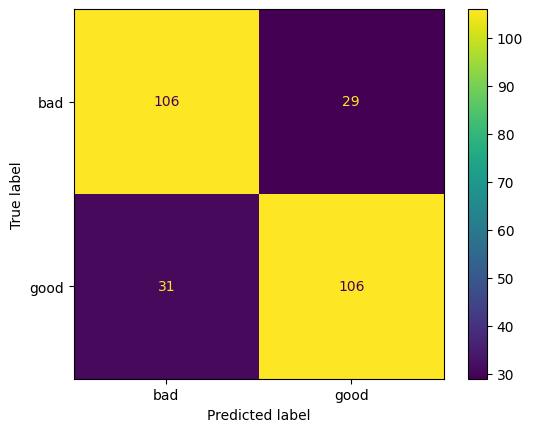

In [49]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cf = confusion_matrix(ytest, ypred_ts)
cfd = ConfusionMatrixDisplay(cf,display_labels=['bad','good'])
cfd.plot()

In [50]:
# Classification report
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred_ts))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       135
           1       0.79      0.77      0.78       137

    accuracy                           0.78       272
   macro avg       0.78      0.78      0.78       272
weighted avg       0.78      0.78      0.78       272

